CHROMA DB :
an open source vector database 
to install it:
    $ pip install chromadb

VECTOR DB :
a specialized filing system for Artificial Intelligence . it stores the data as maths based co-ordinates (vectors) . this allows the computers to search based on meaning , context and , and similiraty 
POPULAR VECTOR DATABASES : FAISS , ChromaDB , Milvus , Weaviate , Qdrant 
core concepts :
* Vector embeddings: machine learning models transform messy human data (text , images , audio) into long strings of numbers called embeddings
* Meaningful Distance: In this numerical spce , items which are similar in meaning end up sitting close to each other . for e.g. the vectors for words "puppy" and "dogs" would be grouped closely while vector for "car" will be far away
* Similiraty search: instead of asking "find me exact match for'puppy' " , we just ask the database to "find me something that means rougly the same thing as 'puppy' "

EMBEDDINGS :
a numeric representation of data that captures its exact meaning or context . 
why embedding ? : 
embedding enables semantic search , similarity matching , recommendations and AI retrieval 
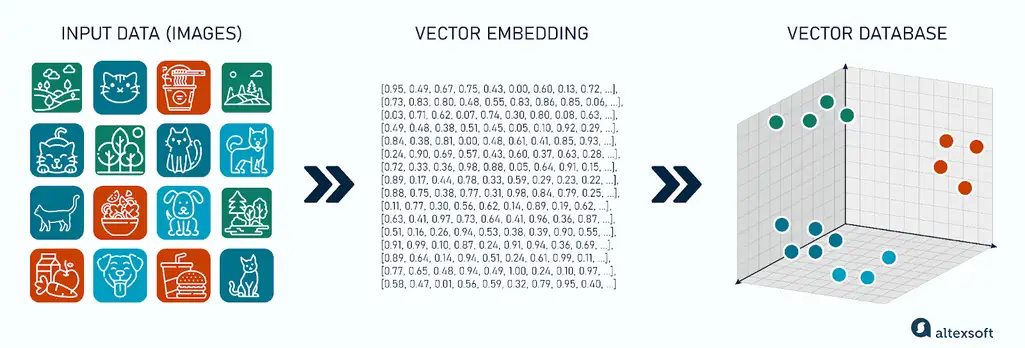

REAL WORLD USE CASES OF VECTOR DB :
chatbots , search engines , customer support , E-commerce , Healthcare , Legal AI . 

HOW DATA IS STORED IN CHROMADB :
* ChromaDB uses SQLite internally to store metadata .
* Vectors are stored in binary format for effeciency
* the chromaDB organises our collection similar to folder structure in our systems 

In [22]:
pip install chromadb

Note: you may need to restart the kernel to use updated packages.


CORE chroma DB Architecture and Data Model :
* Client : a client is the primary interface used to connect to the vector database and perform key operations like creating collections , adding document embeddings , and querying data .
there are multiple types of chromaDB clients which we choose based on our infrastructure needs
    * Ephimeral client (Client) : starts an in memory chromaDB instance , the data is temporary , stays in RAM and wiped once the script or notebook stops running
    * Persistent client (PersistentClient) : Configures chromaDB to save and load data from the local disk path . it prevents data loss between restarts and allows different scripts to use the same DB files .
    * HTTP Client (HttpClient) : used when chroma is running in a client-server mode (e.g. deployed in docker , or deployed on cloud ) . the client communicate with the DB entirely through HTTP/HTTPs requests .
* Collections : a collection in ChromaDB is like a single folder or table used to store our data .inside a collection , every piece of data is stored as an individual record containing four things 
  it holds
  * Documents : the actual texts (e.g. "Bananas are yellow ")
  * Embeddings : a string of numbers that represent the meaning of that text
  * Metadata : extra labels for filtering , like category or date
  * ID : a unique name or number to easily find or change the records
* Tenants and Databases : these are the organizational layers used to isolate and group, and secure data . think of it like folders inside folders on the computer , where tenants are the main top - level folders , databases are subfolders inside them , and collections are the files inside the folder .
  by default , if we dont specify the names of the tenant and the database , it will drop everything in a folder named default_tenant and subfolder default_database 
  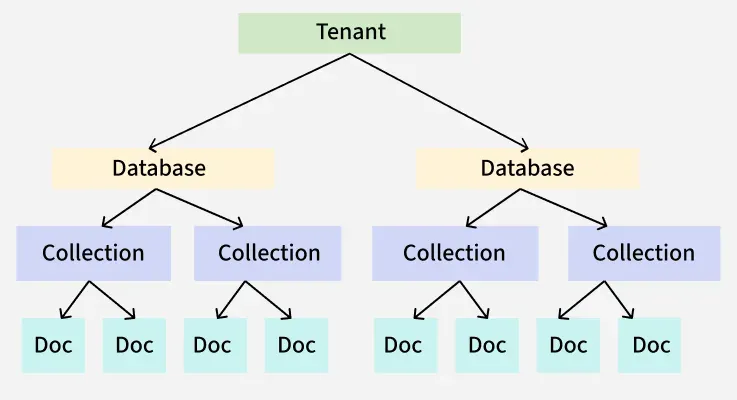

VECTOR AND EMBEDDING MANAGEMENT :
* Embedding functions : chroma requires a model to translate text into high-dimensional vectors . by default , it uses 'all-MiniLM-L6-v2' sentence transformer model locally . we can configure custom functions for providers like openai , cohere , or huggingface
* Documents and IDs : the unstructured textual data we pass into chroma is called the document , and each document requires a user defined string ID for storage and future updates 

In [23]:
# creating a Client 
import chromadb 

client = chromadb.PersistentClient(path = "./my_chromaDB") # this creates a Persistant client , which stays in our storage even after reboot . 
client2 = chromadb.Client() # this one goes when the script stops or the system reboots

SENTANCE TRANSFORMERS :
they are a class of deep-learning models that are designed to convert entire sentances , paragraphs , or images into fixed size dense vectors by capturing the deep sementic meaning and context of the text , enabling the machines to understand how similar 2 pieces of text are . 
to install :
    $ pip install sentence-transformers

WORKFLOW :

Text

  ↓
  
Sentence Transformer

  ↓
  
Embedding Vector

  ↓

ChromaDB

  ↓

Similarity Search

POPULAR MODELS :
* OpenAI
* Google Gemini Embeddings
* BGE
* E5
* all-MiniLM-L6-v2 (fast, 384 dimensions)
* all-mpnet-base-v2 (more accurate, 768 dimensions)
* BAAI/bge-small-en-v1.5
* BAAI/bge-base-en-v1.5
* nomic-ai/nomic-embed-text-v1

In [24]:
pip install sentence-transformers

Note: you may need to restart the kernel to use updated packages.


EMBEDDING FUNCTIONS :
an embedding function wraps an embedding model and use it to convert text into vectors 

In [25]:
# using embedding function 
from chromadb.utils import embedding_functions

sentence_transformer_ef = embedding_functions.SentenceTransformerEmbeddingFunction(
    model_name = "all-MiniLM-L6-v2"
)

In [26]:
# deleting a collection 

client.delete_collection(
    name = "my_recipies"
)

In [27]:
# creating a collection 
collection = client.create_collection(
    name = "my_recipies" , # name of our collection 
    embedding_function = sentence_transformer_ef , # how to convert text 
    metadata = {"description" : "Some of my recipies"} # info about our collection
)

# checking if created 
print(f"{collection.name}")
print(f"{collection.metadata}")

my_recipies
{'description': 'Some of my recipies'}


VECTOR CRUD OPERATIONS :
the standard programtic ways to manage elements inside a collection 
* collection.add() : ingests documents and auto-generates embedding
* collection.get() : retrieves explicitly documents using their IDs
* collection.update() : modifies existing vector values or text data
* collection.upsert() : updates a vectors if the ID exists , or creates a new one if it dosent
* collection.query() : conducts the nearest-neighbor search to return similar documents
* collection.delete_collection(name = "collection_name") : deletes the entire collection 

In [28]:
# adding documents , metadata , id  to the collection 

# document - our actual data
recipies = [
    "mix flour , eggs , and milk to make pankakes ",
    "boil pasta and add tomato sauce with basil ",
    "blend strawberries , banana , yogurt for a smoothie ",
    "grill chicken with lemon and herbs ",
    "bake choclate cake with vanilla frosting ",
]

# metadata - extra information about the document
recipies_metadata = [
    {
        "dish_name" : "Pancakes",
        "meal_type" : "breakfast",
        "preparation_time_minutes" : 20,
        "difficulty" : "easy",
        "vegetarian" : False
    },
     {
        "dish_name" : "Pasta",
        "meal_type" : "dinner",
        "preparation_time_minutes" : 10,
        "difficulty" : "medium",
        "vegetarian" : True
    },
     {
        "dish_name" : "smoothie",
        "meal_type" : "breakfast",
        "preparation_time_minutes" : 5,
        "difficulty" : "easy",
        "vegetarian" : True
    },
     {
        "dish_name" : "grilled chicken",
        "meal_type" : "dinner",
        "preparation_time_minutes" : 45,
        "difficulty" : "medium",
        "vegetarian" : False
    },
     {
        "dish_name" : "Choclate cake",
        "meal_type" : "dessert",
        "preparation_time_minutes" : 60,
        "difficulty" : "hard",
        "vegetarian" : True
    },
]

# ids - unique IDs for each dicument , we choose these
ids = ["recipe_1" , "recipe_2" , "recipe_3" , "recipe_4" , "recipe_5"]

# adding everything to the collection 
collection.add(
    documents = recipies , # the text 
    metadatas = recipies_metadata, # extra information 
    ids = ids, # unique identifiers
)

# check if its added successfully 
print(f"added {collection.count()} recipies ")

added 5 recipies 


In [29]:
# getting all documents from the collection 

data = collection.get() # copy the whole collection into a dictionary 

for i in range(len(data['ids'])):
    print (f"\n ID : {data["ids"][i]}")
    print (f"Document : {data["documents"][i]}")
    print (f"Metadata : {data["metadatas"][i]}")


 ID : recipe_1
Document : mix flour , eggs , and milk to make pankakes 
Metadata : {'difficulty': 'easy', 'vegetarian': False, 'preparation_time_minutes': 20, 'meal_type': 'breakfast', 'dish_name': 'Pancakes'}

 ID : recipe_2
Document : boil pasta and add tomato sauce with basil 
Metadata : {'preparation_time_minutes': 10, 'dish_name': 'Pasta', 'vegetarian': True, 'meal_type': 'dinner', 'difficulty': 'medium'}

 ID : recipe_3
Document : blend strawberries , banana , yogurt for a smoothie 
Metadata : {'meal_type': 'breakfast', 'vegetarian': True, 'dish_name': 'smoothie', 'preparation_time_minutes': 5, 'difficulty': 'easy'}

 ID : recipe_4
Document : grill chicken with lemon and herbs 
Metadata : {'meal_type': 'dinner', 'vegetarian': False, 'preparation_time_minutes': 45, 'difficulty': 'medium', 'dish_name': 'grilled chicken'}

 ID : recipe_5
Document : bake choclate cake with vanilla frosting 
Metadata : {'dish_name': 'Choclate cake', 'meal_type': 'dessert', 'vegetarian': True, 'prepar

In [30]:
# fetching data by ID 

# get specific recipies by their IDs 
result = collection.get(
    ids = ["recipe_1" , "recipe_3"] , # which ids to fetch 
    include = ["documents" , "metadatas"] # what information to return 
)

for i,doc in enumerate(result['documents']) : 
    print(f"Metadata : {result['metadatas'][i]}")
    print(f"Instruction : {doc}")

Metadata : {'vegetarian': False, 'dish_name': 'Pancakes', 'meal_type': 'breakfast', 'preparation_time_minutes': 20, 'difficulty': 'easy'}
Instruction : mix flour , eggs , and milk to make pankakes 
Metadata : {'preparation_time_minutes': 5, 'difficulty': 'easy', 'dish_name': 'smoothie', 'vegetarian': True, 'meal_type': 'breakfast'}
Instruction : blend strawberries , banana , yogurt for a smoothie 


SEMANTIC SEARCH :
semantic search is a search method that looks at the meaning and itnent behind the words we are searching instead of the exact keyword 

why is it smart ? :
* it knows synonyms : it understands that "car" , "auto" , and "vehicle" refer to same thing
* it understands context : it knows the word "python" means programming language when we search for coding tips and snake when we search for a zoo guide
* it grasps conecpts : isntead of just word matching , it converts the meaning of our text into mathematical space to find the documents that share the exact same ideas

In [31]:
# semantic search 

query = "i want to eat something sweet after dinner"

results = collection.query(
    query_texts = [query] , # what we are looking for 
    n_results = 2 , # how many results to return 
    include = ["documents" , "metadatas" , "distances"]
)

for i in range(len(results["documents"][0])) :
    print(f"Dish : {results["metadatas"][0][i]["dish_name"]}")
    print(f"Recipie : {results["documents"][0][i]}")
    print(f"Meal type : {results["metadatas"][0][i]["meal_type"]}")
    print(f"Similarity distance : {results["distances"][0][i]:.4f}\n\n")

Dish : smoothie
Recipie : blend strawberries , banana , yogurt for a smoothie 
Meal type : breakfast
Similarity distance : 0.6296


Dish : grilled chicken
Recipie : grill chicken with lemon and herbs 
Meal type : dinner
Similarity distance : 0.6793


